# Notebook 4: Model Definition and Training (V1)

This notebook defines a 1D CNN + LSTM model for classifying Ethereum
transactions, trains it on the V1 preprocessed and split data,
and evaluates its performance.

## 1. Imports and Initial Setup

In [12]:
# ----- CODE CELL: Imports and Initial Setup -----
import json
from pathlib import Path

import numpy as np
import pandas as pd # Only for loading data if not using direct numpy arrays
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt # For plotting confusion matrix
import seaborn as sns # For plotting confusion matrix


# --- Configuration ---
device = torch.device("cpu")
print(f"Using device: {device}")

# Paths (assuming this script is in 'EthMalViz/notebooks/')
PROJECT_ROOT = Path('..')
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models'
REPORTS_FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures' # For plots

# Ensure output directories exist
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Model V1 specific paths
MODEL_V1_SAVE_NAME = "ethmalviz_cnn_lstm_model_v1.pth"
MODEL_V1_SAVE_PATH = MODEL_DIR / MODEL_V1_SAVE_NAME

# Path to the directory where data splits from notebook 03 were saved
DATA_SPLITS_V1_DIR = PROCESSED_DATA_DIR / "data_splits_v1"

print(f"Model V1 save path: {MODEL_V1_SAVE_PATH}")
print(f"Data splits V1 directory: {DATA_SPLITS_V1_DIR}")
print(f"CUDA available: {torch.cuda.is_available()}") # Should be False

Using device: cpu
Model V1 save path: ../models/ethmalviz_cnn_lstm_model_v1.pth
Data splits V1 directory: ../data/processed/data_splits_v1
CUDA available: False


## 2. Data Loading (Prepared V1 Splits)

Load the pre-split and pre-scaled training, validation, and test datasets
that were prepared and saved by `03_model_development.py`.
Also, load the final function signature mapping to get the vocabulary size.

In [4]:
# ----- CODE CELL: Load Prepared Data Splits -----
print(f"\nAttempting to load V1 data splits from: {DATA_SPLITS_V1_DIR}")

try:
    # Load numerical features (already scaled)
    X_num_train_df = pd.read_parquet(
        DATA_SPLITS_V1_DIR / "X_num_train_scaled_v1.parquet"
    )
    X_num_val_df = pd.read_parquet(
        DATA_SPLITS_V1_DIR / "X_num_val_scaled_v1.parquet"
    )
    X_num_test_df = pd.read_parquet(
        DATA_SPLITS_V1_DIR / "X_num_test_scaled_v1.parquet"
    )

    # Load categorical index features
    X_cat_idx_train_df = pd.read_parquet(
        DATA_SPLITS_V1_DIR / "X_cat_idx_train_v1.parquet"
    )
    X_cat_idx_val_df = pd.read_parquet(
        DATA_SPLITS_V1_DIR / "X_cat_idx_val_v1.parquet"
    )
    X_cat_idx_test_df = pd.read_parquet(
        DATA_SPLITS_V1_DIR / "X_cat_idx_test_v1.parquet"
    )

    # Load target labels
    y_train_df = pd.read_parquet(DATA_SPLITS_V1_DIR / "y_train_v1.parquet")
    y_val_df = pd.read_parquet(DATA_SPLITS_V1_DIR / "y_val_v1.parquet")
    y_test_df = pd.read_parquet(DATA_SPLITS_V1_DIR / "y_test_v1.parquet")

    print("Successfully loaded all V1 data splits.")
    print(f"  X_num_train shape: {X_num_train_df.shape}")
    print(f"  X_cat_idx_train shape: {X_cat_idx_train_df.shape}") # Should be (N,1)
    print(f"  y_train shape: {y_train_df.shape}") # Should be (N,1)

except FileNotFoundError as fnf_e:
    print(f"ERROR: A data split file was not found in {DATA_SPLITS_V1_DIR}.")
    print(f"Specific error: {fnf_e}")
    print(
        "Please ensure '03_model_development.py' was run successfully "
        "and saved all V1 data splits."
    )
    raise
except Exception as e_load_split:
    print(f"An error occurred while loading data splits: {e_load_split}")
    raise

# --- Convert DataFrames to PyTorch Tensors ---
# Numerical features (already scaled)
X_num_train_tensor = torch.tensor(
    X_num_train_df.values, dtype=torch.float32
).to(device)
X_num_val_tensor = torch.tensor(
    X_num_val_df.values, dtype=torch.float32
).to(device)
X_num_test_tensor = torch.tensor(
    X_num_test_df.values, dtype=torch.float32
).to(device)

# Categorical indices (should be LongTensors (int64) for nn.Embedding)
# X_cat_idx_..._df should have one column, e.g., 'function_sig_idx'
X_cat_idx_train_tensor = torch.tensor(
    X_cat_idx_train_df.values, dtype=torch.int64
).to(device)
X_cat_idx_val_tensor = torch.tensor(
    X_cat_idx_val_df.values, dtype=torch.int64
).to(device)
X_cat_idx_test_tensor = torch.tensor(
    X_cat_idx_test_df.values, dtype=torch.int64
).to(device)

# Target labels (should be FloatTensors for BCELoss and unsqueezed)
# y_..._df should have one column, e.g., 'is_malicious'
y_train_tensor = torch.tensor(
    y_train_df.values, dtype=torch.float32
).to(device) # .unsqueeze(1) not needed if y_df is already (N,1)
y_val_tensor = torch.tensor(
    y_val_df.values, dtype=torch.float32
).to(device)
y_test_tensor = torch.tensor(
    y_test_df.values, dtype=torch.float32
).to(device)

# If y_df was loaded as Series, .values gives 1D array, then .unsqueeze(1)
# If y_df was loaded as DataFrame (N,1), .values is already (N,1)
# Let's ensure it's (N,1) for BCELoss
if y_train_tensor.ndim == 1: y_train_tensor = y_train_tensor.unsqueeze(1)
if y_val_tensor.ndim == 1: y_val_tensor = y_val_tensor.unsqueeze(1)
if y_test_tensor.ndim == 1: y_test_tensor = y_test_tensor.unsqueeze(1)


print("\nAll V1 data splits converted to PyTorch tensors.")
print(f"  X_num_train_tensor shape: {X_num_train_tensor.shape}")
print(f"  X_cat_idx_train_tensor shape: {X_cat_idx_train_tensor.shape}")
print(f"  y_train_tensor shape: {y_train_tensor.shape}")


# Define NUM_NUMERICAL_FEATURES_MODEL based on the loaded data
NUM_NUMERICAL_FEATURES_MODEL = X_num_train_df.shape[1]
print(
    f"Number of numerical features for model (from loaded data): "
    f"{NUM_NUMERICAL_FEATURES_MODEL}"
)


Attempting to load V1 data splits from: ../data/processed/data_splits_v1
Successfully loaded all V1 data splits.
  X_num_train shape: (50532, 10)
  X_cat_idx_train shape: (50532, 1)
  y_train shape: (50532, 1)

All V1 data splits converted to PyTorch tensors.
  X_num_train_tensor shape: torch.Size([50532, 10])
  X_cat_idx_train_tensor shape: torch.Size([50532, 1])
  y_train_tensor shape: torch.Size([50532, 1])
Number of numerical features for model (from loaded data): 10


## 3. Model Definition (1D CNN + LSTM - V1)

Define the neural network architecture using PyTorch. The model combines
an embedding layer for function signatures, a 1D CNN to process these
embeddings, and an LSTM to process the sequence of combined numerical
and CNN-processed categorical features.

In [5]:
# ----- CODE CELL: Model Definition -----
class EthMalModelV1(nn.Module):
    def __init__(self, num_numerical_features, vocab_size, embedding_dim,
                 cnn_out_channels, cnn_kernel_size,
                 lstm_hidden_dim, lstm_num_layers, dropout_rate):
        super(EthMalModelV1, self).__init__()

        self.embedding_layer = nn.Embedding( # Renamed for clarity
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=None # If 0 is a padding index, set padding_idx=0
        )
        
        # 1D CNN to process embeddings
        # Input: (batch_size, embedding_dim, sequence_length_of_embeddings)
        # Here, each transaction has one function signature index, so after
        # embedding and permuting, we can treat it as seq_len=1.
        self.cnn_layer = nn.Conv1d( # Renamed
            in_channels=embedding_dim, # Embeddings are channels
            out_channels=cnn_out_channels,
            kernel_size=cnn_kernel_size, # Often 1 if sequence length is 1
            # padding is (kernel_size-1)//2 for 'same' padding if stride=1
            padding=0 if cnn_kernel_size == 1 else (cnn_kernel_size - 1) // 2
        )
        self.cnn_activation = nn.ReLU() # Renamed
        # Adaptive pooling to get a fixed-size output from CNN
        self.cnn_pooling = nn.AdaptiveMaxPool1d(output_size=1) # Renamed

        # LSTM layer
        # Input to LSTM: concatenated numerical features and CNN output
        # We treat each transaction as a sequence of length 1 for the LSTM
        self.lstm_layer = nn.LSTM( # Renamed
            input_size=num_numerical_features + cnn_out_channels,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_num_layers,
            batch_first=True, # Input format: (batch, seq_len, feature_dim)
            dropout=dropout_rate if lstm_num_layers > 1 else 0.0,
            bidirectional=False # Can be True for bi-directional LSTM
        )
        
        self.lstm_dropout = nn.Dropout(dropout_rate) # Renamed
        
        # Fully connected output layer
        self.output_fc = nn.Linear(lstm_hidden_dim, 1) # Renamed
        self.output_activation = nn.Sigmoid() # Renamed

    def forward(self, x_numerical_input, x_categorical_indices): # Renamed
        # x_categorical_indices shape: (batch_size, 1) as loaded
        # Embedding layer expects (batch_size, seq_len_indices)
        # We need to squeeze the last dimension if it's (N,1)
        if x_categorical_indices.ndim == 2 and x_categorical_indices.shape[1] == 1:
            x_categorical_indices = x_categorical_indices.squeeze(1)
        
        # embedded_features shape: (batch_size, embedding_dim)
        embedded_features = self.embedding_layer(x_categorical_indices)
        
        # Reshape for Conv1D: (batch_size, channels=embedding_dim, length=1)
        cnn_input = embedded_features.unsqueeze(2)
        
        cnn_output_raw = self.cnn_layer(cnn_input) # (batch, cnn_out, 1)
        cnn_output_activated = self.cnn_activation(cnn_output_raw)
        cnn_output_pooled = self.cnn_pooling(cnn_output_activated)
        # Flatten CNN output: (batch_size, cnn_out_channels)
        cnn_features_flat = cnn_output_pooled.squeeze(2)
        
        # Concatenate numerical features with CNN-processed categorical features
        # x_numerical_input shape: (batch_size, num_numerical_features)
        lstm_input_combined = torch.cat(
            (x_numerical_input, cnn_features_flat), dim=1
        )
        
        # LSTM expects input of shape (batch, seq_len, input_size)
        # Treat each transaction as a sequence of length 1
        lstm_input_reshaped = lstm_input_combined.unsqueeze(1)
        
        lstm_output_raw, (hidden_state, cell_state) = self.lstm_layer(
            lstm_input_reshaped
        )
        
        # Use the output of the last LSTM cell from the last layer
        # lstm_output_raw shape: (batch_size, 1, lstm_hidden_dim)
        # Squeeze the sequence length dimension
        lstm_output_final = lstm_output_raw.squeeze(1)
        # Alternatively, use hidden_state[-1] if unidirectional

        lstm_output_dropped = self.lstm_dropout(lstm_output_final)
        logits = self.output_fc(lstm_output_dropped)
        probabilities = self.output_activation(logits) # Final output (batch,1)
        
        return probabilities

print("Model architecture EthMalModelV1 defined.")

Model architecture EthMalModelV1 defined.


## 4. Model V1 Initialization and Hyperparameters

Create an instance of `EthMalModelV1`, define hyperparameters,
and set up the optimizer and loss function. The vocabulary size for
function signatures is loaded from the `function_signature_map_final.json`
file created by `03_model_development.py`.

In [6]:
# ----- CODE CELL: Model V1 Initialization and Hyperparameters -----
# --- 4.1. Load Final Function Signature Mapping ---
# This path should point to the map created by notebook 03
path_to_final_sig_map = MODEL_DIR / 'function_signature_map_final.json'
try:
    with open(path_to_final_sig_map, 'r') as f_map_final: # Renamed
        data_final_sig_map = json.load(f_map_final) # Renamed
    vocab_size_for_model = data_final_sig_map['vocab_size'] # Renamed
    print(
        "Successfully loaded FINAL signature mapping. "
        f"Vocabulary size: {vocab_size_for_model}"
    )
except FileNotFoundError:
    print(f"ERROR: Sig map file not found: {path_to_final_sig_map}")
    print("Ensure '03_model_development.py' created the FINAL map.")
    raise
except Exception as e_map_load_final: # Renamed
    print(f"Error loading final signature mapping: {e_map_load_final}")
    raise

# --- 4.2. Define Model V1 Hyperparameters ---
# NUM_NUMERICAL_FEATURES_MODEL was defined in Cell 2 after loading data
print(
    f"Number of numerical features for V1 model: "
    f"{NUM_NUMERICAL_FEATURES_MODEL}"
)

EMBEDDING_DIM_V1 = 32
CNN_OUT_CHANNELS_V1 = 16
CNN_KERNEL_SIZE_V1 = 1 # For embeddings treated as (Channels, SeqLen=1)
LSTM_HIDDEN_DIM_V1 = 64
LSTM_NUM_LAYERS_V1 = 1 # Start with 1 layer, can increase
DROPOUT_RATE_V1 = 0.3

# --- 4.3. Initialize Model V1 ---
model_v1 = EthMalModelV1( # Use the defined model class
    num_numerical_features=NUM_NUMERICAL_FEATURES_MODEL,
    vocab_size=vocab_size_for_model, # From loaded final map
    embedding_dim=EMBEDDING_DIM_V1,
    cnn_out_channels=CNN_OUT_CHANNELS_V1,
    cnn_kernel_size=CNN_KERNEL_SIZE_V1,
    lstm_hidden_dim=LSTM_HIDDEN_DIM_V1,
    lstm_num_layers=LSTM_NUM_LAYERS_V1,
    dropout_rate=DROPOUT_RATE_V1
).to(device)

# --- 4.4. Define Loss Function and Optimizer for V1 ---
# BCELoss expects target to be same shape as output (batch_size, 1)
criterion_v1 = nn.BCELoss() 
optimizer_v1 = optim.Adam(model_v1.parameters(), lr=0.001) # Adam optimizer

print("\nModel EthMalModelV1 initialized and moved to device.")
print("Optimizer and Loss function for V1 defined.")

Successfully loaded FINAL signature mapping. Vocabulary size: 138
Number of numerical features for V1 model: 10

Model EthMalModelV1 initialized and moved to device.
Optimizer and Loss function for V1 defined.


## 5. Training and Evaluation Utility Functions

Define helper functions for the training loop and for evaluating
model performance on a given dataset.

In [7]:
# ----- CODE CELL: Training and Evaluation Utility Functions -----
def calculate_model_metrics_v1(y_true_numpy, y_pred_numpy): # Renamed
    # Ensure inputs are 1D numpy arrays of integers (0 or 1)
    y_true_flat = np.array(y_true_numpy).flatten().astype(int)
    y_pred_flat = np.array(y_pred_numpy).flatten().astype(int)
    
    acc_score = accuracy_score(y_true_flat, y_pred_flat)
    prec_score = precision_score(y_true_flat, y_pred_flat, zero_division=0)
    rec_score = recall_score(y_true_flat, y_pred_flat, zero_division=0)
    f1_val_score = f1_score(y_true_flat, y_pred_flat, zero_division=0) # Renamed
    try:
        roc_auc = roc_auc_score(y_true_flat, y_pred_flat)
    except ValueError: # Only one class present in y_true or y_pred
        roc_auc = 0.0 if len(np.unique(y_true_flat)) > 1 else 0.5

    return acc_score, prec_score, rec_score, f1_val_score, roc_auc

def train_single_epoch_v1( # Renamed
    model_to_train, data_optim, loss_crit, 
    x_num_epoch, x_cat_epoch, y_epoch, batch_size_epoch
):
    model_to_train.train() # Set model to training mode
    total_epoch_loss = 0.0
    
    # Create DataLoader for batching within the epoch
    epoch_dataset = TensorDataset(x_num_epoch, x_cat_epoch, y_epoch)
    epoch_loader = DataLoader(
        epoch_dataset, batch_size=batch_size_epoch, shuffle=True
    )
    
    for batch_idx, (x_n_batch, x_c_batch, y_b) in enumerate(epoch_loader): # Renamed
        data_optim.zero_grad() # Clear previous gradients
        
        # Forward pass
        # Ensure x_c_batch is correctly shaped for embedding if needed
        # Model's forward method handles x_c_batch.squeeze(1) if it's (N,1)
        batch_predictions = model_to_train(x_n_batch, x_c_batch)
        
        # Calculate loss
        # Ensure batch_y shape matches batch_predictions (e.g., (batch_size,1))
        current_loss = loss_crit(batch_predictions, y_b)
        
        current_loss.backward() # Backpropagate the loss
        data_optim.step() # Update model weights
        
        total_epoch_loss += current_loss.item()
        
        if batch_idx > 0 and batch_idx % 200 == 0: # Log every 200 batches
            print(
                f"    Epoch Batch {batch_idx}/{len(epoch_loader)}, "
                f"Loss: {current_loss.item():.4f}"
            )
            
    avg_loss_for_epoch = total_epoch_loss / len(epoch_loader)
    return avg_loss_for_epoch

def evaluate_current_model_v1( # Renamed
    model_to_eval, loss_crit, 
    x_num_eval, x_cat_eval, y_eval
):
    model_to_eval.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations for evaluation
        eval_predictions = model_to_eval(x_num_eval, x_cat_eval)
        eval_loss = loss_crit(eval_predictions, y_eval)
        
        # Convert probabilities to binary predictions
        eval_pred_probs_np = eval_predictions.cpu().numpy()
        eval_pred_labels_np = (eval_pred_probs_np > 0.5).astype(int)
        
        eval_true_labels_np = y_eval.cpu().numpy()
        
        # Calculate metrics
        acc, prec, rec, f1, roc = calculate_model_metrics_v1(
            eval_true_labels_np, eval_pred_labels_np
        )
        
    return eval_loss.item(), acc, prec, rec, f1, roc
# ----- CODE CELL END -----

## 6. Main Training Loop for Model V1

This section orchestrates the training process over multiple epochs,
including validation, early stopping, and saving the best model.

In [8]:
# ----- CODE CELL: Main Training Loop -----
# Training Hyperparameters
NUM_EPOCHS_V1 = 20 # Increase for potentially better results
BATCH_SIZE_V1 = 128
LEARNING_RATE_V1 = 0.001 # Defined when optimizer_v1 was created
EARLY_STOPPING_PATIENCE_V1 = 5 # More patience

# Re-initialize optimizer if learning rate needs to be set here
# optimizer_v1 = optim.Adam(model_v1.parameters(), lr=LEARNING_RATE_V1)

# Tracking variables for best model and early stopping
best_validation_loss_v1 = float('inf')
epochs_no_improve_v1 = 0

# Lists to store metrics for plotting later
train_losses_v1 = []
val_losses_v1 = []
val_f1_scores_v1 = []

print("\nStarting Model V1 training...")
for epoch_num in range(NUM_EPOCHS_V1): # Renamed loop variable
    # Train for one epoch
    avg_train_loss_epoch = train_single_epoch_v1( # Use renamed function
        model_v1, optimizer_v1, criterion_v1, 
        X_num_train_tensor, X_cat_idx_train_tensor, y_train_tensor, 
        BATCH_SIZE_V1
    )
    train_losses_v1.append(avg_train_loss_epoch)

    # Evaluate on the validation set
    val_loss_epoch, val_acc_epoch, val_prec_epoch, \
    val_rec_epoch, val_f1_epoch, val_roc_epoch = evaluate_current_model_v1( # Use renamed
        model_v1, criterion_v1, 
        X_num_val_tensor, X_cat_idx_val_tensor, y_val_tensor
    )
    val_losses_v1.append(val_loss_epoch)
    val_f1_scores_v1.append(val_f1_epoch)
    
    print(f"\nEpoch {epoch_num+1}/{NUM_EPOCHS_V1} Summary:")
    print(f"  Training Loss:   {avg_train_loss_epoch:.4f}")
    print(f"  Validation Loss: {val_loss_epoch:.4f}")
    print(f"  Validation Accuracy: {val_acc_epoch:.4f}")
    print(f"  Validation Precision: {val_prec_epoch:.4f}")
    print(f"  Validation Recall: {val_rec_epoch:.4f}")
    print(f"  Validation F1 Score: {val_f1_epoch:.4f}")
    print(f"  Validation ROC AUC: {val_roc_epoch:.4f}")

    # Early Stopping and Best Model Saving
    if val_loss_epoch < best_validation_loss_v1:
        best_validation_loss_v1 = val_loss_epoch
        epochs_no_improve_v1 = 0
        torch.save(model_v1.state_dict(), MODEL_V1_SAVE_PATH)
        print(
            f"  (Best validation loss: {best_validation_loss_v1:.4f}. "
            "Model V1 saved.)"
        )
    else:
        epochs_no_improve_v1 += 1
        print(
            f"  (No improvement in validation loss for "
            f"{epochs_no_improve_v1} epochs.)"
        )
        if epochs_no_improve_v1 >= EARLY_STOPPING_PATIENCE_V1:
            print("  Early stopping triggered for Model V1.")
            break

print("\nModel V1 training complete.")

# Load the best performing model checkpoint for final evaluation
if MODEL_V1_SAVE_PATH.exists():
    model_v1.load_state_dict(torch.load(MODEL_V1_SAVE_PATH))
    print(f"Best Model V1 loaded from {MODEL_V1_SAVE_PATH}")
else:
    print("WARNING: No best model checkpoint found. Using last state.")
# ----- CODE CELL END -----


Starting Model V1 training...
    Epoch Batch 200/395, Loss: 0.0191

Epoch 1/20 Summary:
  Training Loss:   0.1159
  Validation Loss: 0.0117
  Validation Accuracy: 0.9968
  Validation Precision: 0.9970
  Validation Recall: 0.9924
  Validation F1 Score: 0.9947
  Validation ROC AUC: 0.9956
  (Best validation loss: 0.0117. Model V1 saved.)
    Epoch Batch 200/395, Loss: 0.0027

Epoch 2/20 Summary:
  Training Loss:   0.0074
  Validation Loss: 0.0076
  Validation Accuracy: 0.9981
  Validation Precision: 0.9994
  Validation Recall: 0.9943
  Validation F1 Score: 0.9968
  Validation ROC AUC: 0.9970
  (Best validation loss: 0.0076. Model V1 saved.)
    Epoch Batch 200/395, Loss: 0.0016

Epoch 3/20 Summary:
  Training Loss:   0.0051
  Validation Loss: 0.0066
  Validation Accuracy: 0.9973
  Validation Precision: 0.9952
  Validation Recall: 0.9961
  Validation F1 Score: 0.9956
  Validation ROC AUC: 0.9970
  (Best validation loss: 0.0066. Model V1 saved.)
    Epoch Batch 200/395, Loss: 0.0104

Epo

## 7. Final Evaluation on Test Set (Model V1)

Evaluate the performance of the best trained Model V1 on the held-out
test set. This provides an unbiased estimate of the model's
generalization performance on unseen data.


--- Final Evaluation of Model V1 on Test Set ---
  Test Loss:      0.0019
  Test Accuracy:  0.9993
  Test Precision: 0.9991
  Test Recall:    0.9985
  Test F1 Score:  0.9988
  Test ROC AUC:   0.9990

Saved training history plot to ../reports/figures/model_v1_training_history.png


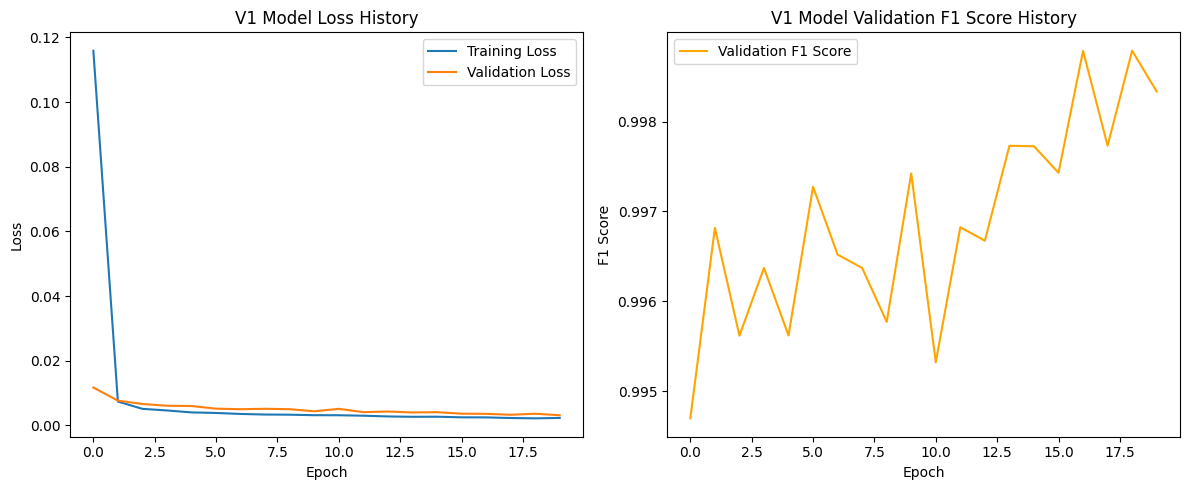

In [13]:
# ----- CODE CELL: Final Evaluation on Test Set -----
# Evaluate the best model on the test set
(test_loss_v1, test_acc_v1, test_prec_v1, 
 test_rec_v1, test_f1_v1, test_roc_v1) = evaluate_current_model_v1( # Use renamed
    model_v1, criterion_v1, 
    X_num_test_tensor, X_cat_idx_test_tensor, y_test_tensor
)

print("\n--- Final Evaluation of Model V1 on Test Set ---")
print(f"  Test Loss:      {test_loss_v1:.4f}")
print(f"  Test Accuracy:  {test_acc_v1:.4f}")
print(f"  Test Precision: {test_prec_v1:.4f}")
print(f"  Test Recall:    {test_rec_v1:.4f}")
print(f"  Test F1 Score:  {test_f1_v1:.4f}")
print(f"  Test ROC AUC:   {test_roc_v1:.4f}")

# Optional: Plot training history (loss, F1 score)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses_v1, label='Training Loss')
plt.plot(val_losses_v1, label='Validation Loss')
plt.title('V1 Model Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_f1_scores_v1, label='Validation F1 Score', color='orange')
plt.title('V1 Model Validation F1 Score History')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.tight_layout()
try:
    history_plot_path = REPORTS_FIGURES_DIR / 'model_v1_training_history.png'
    plt.savefig(history_plot_path, dpi=300)
    print(f"\nSaved training history plot to {history_plot_path}")
except Exception as e_hist_plot:
    print(f"Error saving history plot: {e_hist_plot}")
plt.show()

# ----- CODE CELL END -----

## 8. Analysis of Predictions (Optional for Model V1)

Further analyze the model's predictions, such as inspecting
misclassified examples or plotting a confusion matrix.


Saved confusion matrix plot to ../reports/figures/model_v1_confusion_matrix.png


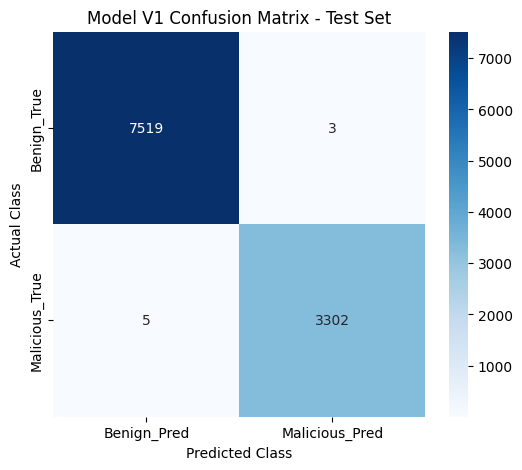


EthMalViz Model V1 training and evaluation script complete.


In [14]:
# ----- CODE CELL: Analyze Predictions (Optional) -----
# Get predictions on test set again (or use from evaluate_model)
model_v1.eval()
with torch.no_grad():
    test_outputs_final = model_v1(
        X_num_test_tensor, X_cat_idx_test_tensor
    ) # Output (N,1)
    test_pred_probs_final_np = test_outputs_final.cpu().numpy()
    test_pred_labels_final_np = (test_pred_probs_final_np > 0.5).astype(int)
    test_true_labels_final_np = y_test_tensor.cpu().numpy()

# Confusion Matrix
cm = confusion_matrix(test_true_labels_final_np, test_pred_labels_final_np)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign_Pred', 'Malicious_Pred'],
            yticklabels=['Benign_True', 'Malicious_True'])
plt.title('Model V1 Confusion Matrix - Test Set')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
try:
    cm_plot_path = REPORTS_FIGURES_DIR / 'model_v1_confusion_matrix.png'
    plt.savefig(cm_plot_path, dpi=300)
    print(f"\nSaved confusion matrix plot to {cm_plot_path}")
except Exception as e_cm_plot:
    print(f"Error saving confusion matrix plot: {e_cm_plot}")
plt.show()

print("\nEthMalViz Model V1 training and evaluation script complete.")
# ----- CODE CELL END -----